# House Prices EDA and Preprocessing - 15 Selected Fields

            Notebook này rebuild phase feature selection, EDA và preprocessing cho
            Kaggle House Prices. Scope dừng ở preprocessing: không train model,
            không evaluate model.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_DIR = Path.cwd().parents[1] if Path.cwd().name == "house_prices" else Path("../../").resolve()
DATA_DIR = PROJECT_DIR / "data" / "raw"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "preprocessing"
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
PREPROCESSOR_PATH = ARTIFACT_DIR / "house_prices_preprocessor.pkl"
PROCESSED_TRAIN_PATH = ARTIFACT_DIR / "processed_train.csv"
PROCESSED_TEST_PATH = ARTIFACT_DIR / "processed_test.csv"
FEATURE_NOTES_PATH = ARTIFACT_DIR / "feature_notes.csv"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

In [7]:
import sys

src_path = PROJECT_DIR / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from ml.preprocessing import (
    FEATURE_COLUMNS,
    FEATURE_NOTES,
    NOMINAL_FEATURES,
    NUMERIC_FEATURES,
    ORDINAL_FEATURES,
    TARGET_COLUMN,
    fit_transform_house_prices,
    save_feature_notes,
    transform_house_prices,
)

In [8]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
display(train_df[FEATURE_COLUMNS + [TARGET_COLUMN]].head())

Train shape: (1460, 81)
Test shape: (1459, 80)


,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,Neighborhood,GarageType,ExterQual,KitchenQual,BsmtQual,SalePrice
0,7,1710,2,548,856,856,2,8,2003,2003,CollgCr,Attchd,Gd,Gd,Gd,208500
1,6,1262,2,460,1262,1262,2,6,1976,1976,Veenker,Attchd,TA,TA,Gd,181500
2,7,1786,2,608,920,920,2,6,2001,2002,CollgCr,Attchd,Gd,Gd,Gd,223500
3,7,1717,3,642,756,961,1,7,1915,1970,Crawfor,Detchd,TA,Gd,TA,140000
4,8,2198,3,836,1145,1145,2,9,2000,2000,NoRidge,Attchd,Gd,Gd,Gd,250000


## Feature Selection Rationale

            15 fields được chọn để cân bằng tín hiệu numeric mạnh với
            categorical/ordinal có ý nghĩa domain rõ ràng. Numeric features
            được scale; nominal categorical được one-hot; quality fields được
            ordinal encode theo thứ tự chất lượng.

In [9]:
feature_notes = pd.DataFrame(FEATURE_NOTES)
display(feature_notes)

,field,type,signal,preprocessing
0,OverallQual,numeric,Strongest numeric signal; corr with SalePrice ...,"Median impute fallback, then StandardScaler."
1,GrLivArea,numeric,Above-ground living area has strong positive p...,"Median impute fallback, then StandardScaler."
2,GarageCars,numeric,Garage capacity tracks higher-value homes.,"Fill missing with 0, then StandardScaler."
3,GarageArea,numeric,Garage size is strongly related to price and g...,"Fill missing with 0, then StandardScaler."
4,TotalBsmtSF,numeric,Basement area adds usable space and correlates...,"Fill missing with 0, then StandardScaler."
5,1stFlrSF,numeric,First-floor size is a strong area-based price ...,"Median impute fallback, then StandardScaler."
6,FullBath,numeric,Bathroom count reflects utility and home size.,"Median impute fallback, then StandardScaler."
7,TotRmsAbvGrd,numeric,Room count captures scale of above-ground livi...,"Median impute fallback, then StandardScaler."
8,YearBuilt,numeric,Newer homes generally command higher sale prices.,"Median impute fallback, then StandardScaler."
9,YearRemodAdd,numeric,Recent remodeling improves perceived condition...,"Median impute fallback, then StandardScaler."


## Data Overview and Missing Values

In [10]:
selected_train = train_df[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
selected_test = test_df[FEATURE_COLUMNS].copy()

dtype_missing = pd.DataFrame({
    "dtype": selected_train[FEATURE_COLUMNS].dtypes.astype(str),
    "missing_train": selected_train[FEATURE_COLUMNS].isna().sum(),
    "missing_test": selected_test[FEATURE_COLUMNS].isna().sum(),
    "missing_train_pct": selected_train[FEATURE_COLUMNS].isna().mean().round(4),
    "missing_test_pct": selected_test[FEATURE_COLUMNS].isna().mean().round(4),
    "nunique_train": selected_train[FEATURE_COLUMNS].nunique(dropna=True),
})
display(dtype_missing)

,dtype,missing_train,missing_test,missing_train_pct,missing_test_pct,nunique_train
OverallQual,int64,0,0,0.0000,0.0000,10
GrLivArea,int64,0,0,0.0000,0.0000,861
GarageCars,int64,0,1,0.0000,0.0007,5
GarageArea,int64,0,1,0.0000,0.0007,441
TotalBsmtSF,int64,0,1,0.0000,0.0007,721
1stFlrSF,int64,0,0,0.0000,0.0000,753
FullBath,int64,0,0,0.0000,0.0000,4
TotRmsAbvGrd,int64,0,0,0.0000,0.0000,12
YearBuilt,int64,0,0,0.0000,0.0000,112
YearRemodAdd,int64,0,0,0.0000,0.0000,61


## Target Distribution

            SalePrice lệch phải rõ rệt; log1p(SalePrice) gần đối xứng hơn nên
            nên dùng cho phase train sau.

{'saleprice_skew': 1.8828757597682129, 'log_saleprice_skew': 0.12134661989685333}


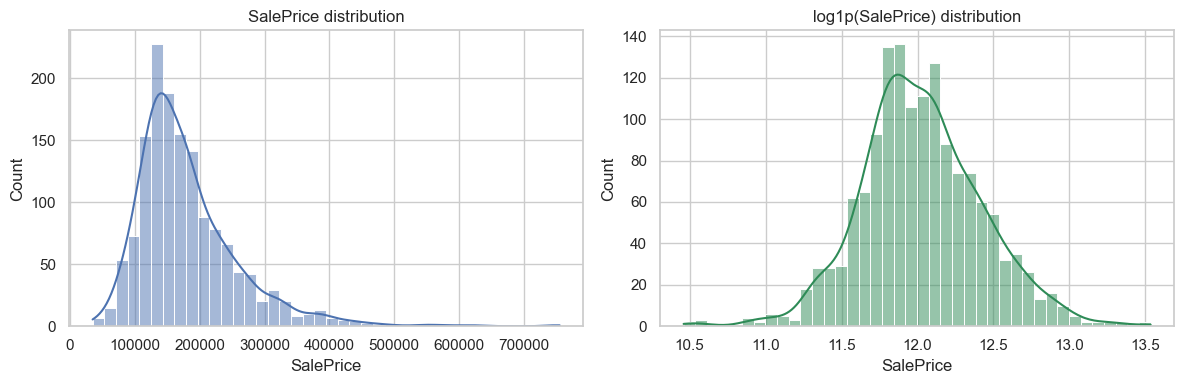

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_df[TARGET_COLUMN], kde=True, bins=40, ax=axes[0])
axes[0].set_title("SalePrice distribution")
sns.histplot(
    np.log1p(train_df[TARGET_COLUMN]),
    kde=True,
    bins=40,
    ax=axes[1],
    color="seagreen",
)
axes[1].set_title("log1p(SalePrice) distribution")
plt.tight_layout()
print({
    "saleprice_skew": float(train_df[TARGET_COLUMN].skew()),
    "log_saleprice_skew": float(np.log1p(train_df[TARGET_COLUMN]).skew()),
})

## Numeric Feature EDA

,count,mean,std,min,25%,50%,75%,max
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
GrLivArea,1460.0,1515.463699,525.480383,334.0,1129.50,1464.0,1776.75,5642.0
GarageCars,1460.0,1.767123,0.747315,0.0,1.00,2.0,2.00,4.0
GarageArea,1460.0,472.980137,213.804841,0.0,334.50,480.0,576.00,1418.0
TotalBsmtSF,1460.0,1057.429452,438.705324,0.0,795.75,991.5,1298.25,6110.0
1stFlrSF,1460.0,1162.626712,386.587738,334.0,882.00,1087.0,1391.25,4692.0
FullBath,1460.0,1.565068,0.550916,0.0,1.00,2.0,2.00,3.0
TotRmsAbvGrd,1460.0,6.517808,1.625393,2.0,5.00,6.0,7.00,14.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0


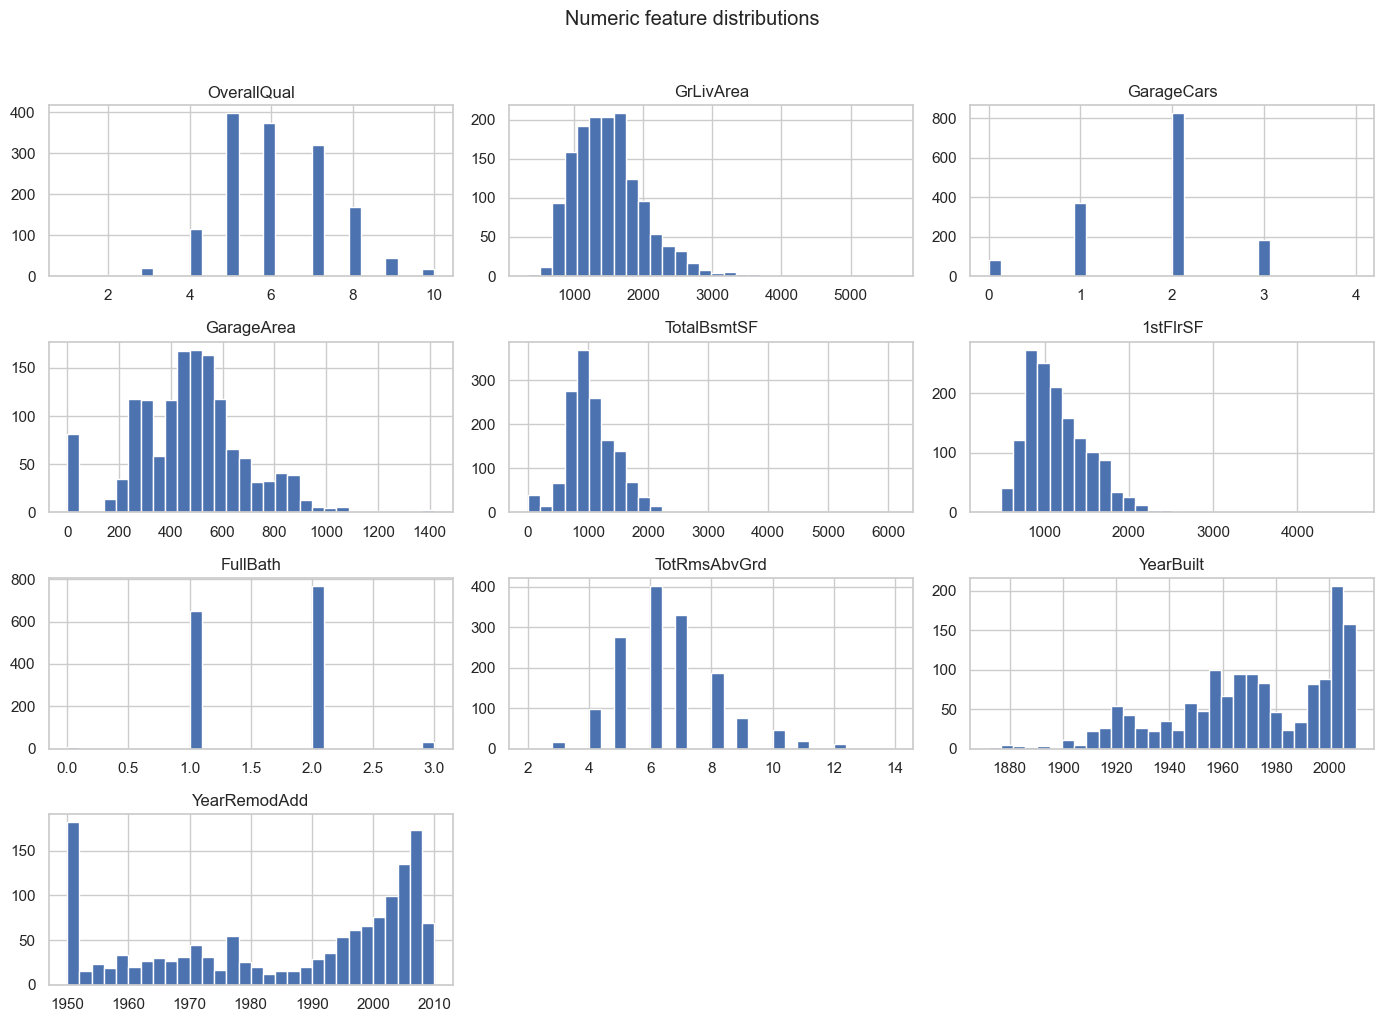

In [12]:
display(train_df[NUMERIC_FEATURES].describe().T)

train_df[NUMERIC_FEATURES].hist(figsize=(14, 10), bins=30)
plt.suptitle("Numeric feature distributions", y=1.02)
plt.tight_layout()

,corr_with_saleprice
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897
YearRemodAdd,0.507101


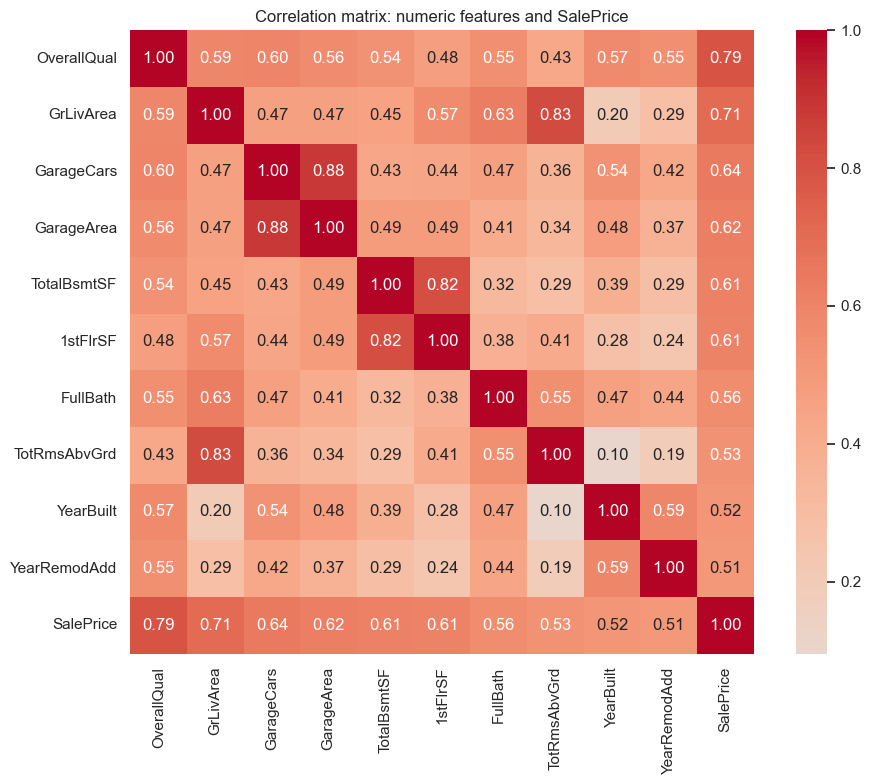

In [13]:
corr = train_df[NUMERIC_FEATURES + [TARGET_COLUMN]].corr(numeric_only=True)
price_corr = corr[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(
    key=lambda s: s.abs(),
    ascending=False,
)
display(price_corr.to_frame("corr_with_saleprice"))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix: numeric features and SalePrice")
plt.tight_layout()

## Categorical Feature EDA

In [14]:
for col in NOMINAL_FEATURES + ORDINAL_FEATURES:
    print(f"\n{col}")
    display(train_df[col].value_counts(dropna=False).to_frame("count"))
    summary = (
        train_df.groupby(col, dropna=False)[TARGET_COLUMN]
        .agg(["count", "median", "mean"])
        .sort_values("median", ascending=False)
    )
    display(summary)


Neighborhood


,count
Neighborhood,
NAmes,225
CollgCr,150
OldTown,113
Edwards,100
Somerst,86
Gilbert,79
NridgHt,77
Sawyer,74
NWAmes,73


,count,median,mean
Neighborhood,,,
NridgHt,77,315000.0,316270.623377
NoRidge,41,301500.0,335295.317073
StoneBr,25,278000.0,310499.000000
Timber,38,228475.0,242247.447368
Somerst,86,225500.0,225379.837209
Veenker,11,218000.0,238772.727273
Crawfor,51,200624.0,210624.725490
ClearCr,28,200250.0,212565.428571
CollgCr,150,197200.0,197965.773333



GarageType


,count
GarageType,
Attchd,870
Detchd,387
BuiltIn,88
NaN,81
Basment,19
CarPort,9
2Types,6


...

,count
KitchenQual,
TA,735
Gd,586
Ex,100
Fa,39


,count,median,mean
KitchenQual,,,
Ex,100,316750.0,328554.670000
Gd,586,201400.0,212116.023891
TA,735,137000.0,139962.511565
Fa,39,115000.0,105565.205128



BsmtQual


,count
BsmtQual,
TA,649
Gd,618
Ex,121
NaN,37
Fa,35


,count,median,mean
BsmtQual,,,
Ex,121,318000.0,327041.041322
Gd,618,192070.0,202688.478964
TA,649,135500.0,140759.818182
Fa,35,112000.0,115692.028571
NaN,37,101800.0,105652.891892


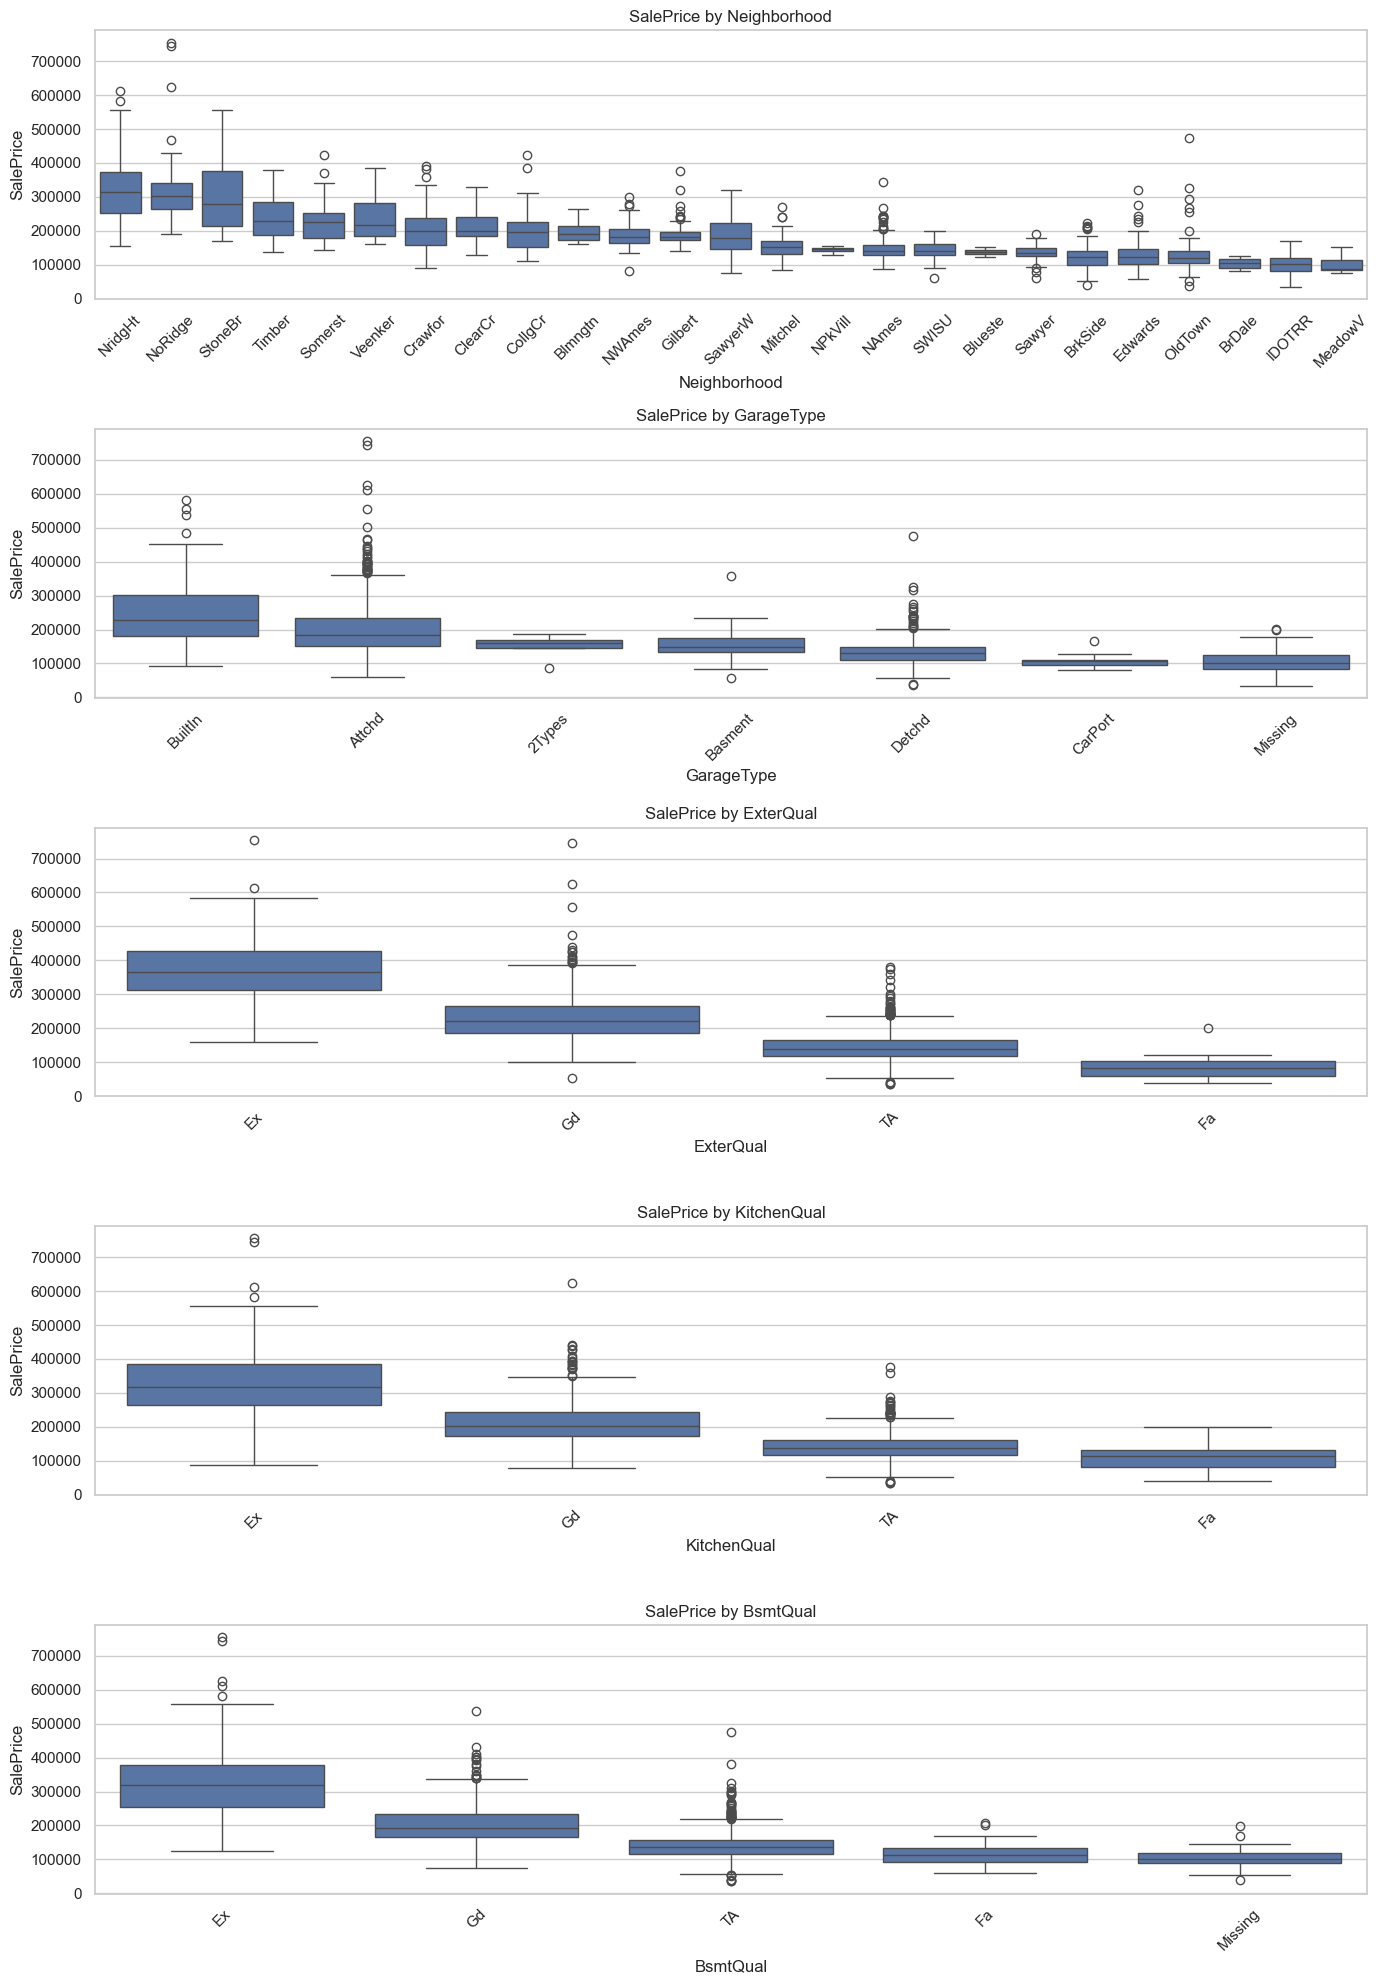

In [16]:
categorical_cols = NOMINAL_FEATURES + ORDINAL_FEATURES
fig, axes = plt.subplots(
    len(categorical_cols),
    1,
    figsize=(14, 4 * len(categorical_cols)),
)
for ax, col in zip(axes, categorical_cols):
    plot_data = train_df[[col, TARGET_COLUMN]].copy()
    plot_data[col] = plot_data[col].fillna("Missing").astype(str)
    order = (
        plot_data.groupby(col)[TARGET_COLUMN]
        .median()
        .sort_values(ascending=False)
        .index
    )
    sns.boxplot(data=plot_data, x=col, y=TARGET_COLUMN, order=order, ax=ax)
    ax.set_title(f"SalePrice by {col}")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

## Outlier Detection

            Các điểm diện tích rất lớn nhưng giá thấp cần ghi chú cho phase
            train sau. Notebook này chỉ phát hiện và ghi nhận, chưa drop rows để
            tránh thay đổi dữ liệu trước khi có model experiment.

In [ ]:
outlier_rules = {
    "GrLivArea_gt_4000_low_price": (
        (train_df["GrLivArea"] > 4000)
        & (train_df[TARGET_COLUMN] < 300000)
    ),
    "TotalBsmtSF_gt_5000": train_df["TotalBsmtSF"] > 5000,
    "GarageArea_gt_1200": train_df["GarageArea"] > 1200,
    "SalePrice_gt_700000": train_df[TARGET_COLUMN] > 700000,
}
outlier_summary = pd.Series(
    {name: int(mask.sum()) for name, mask in outlier_rules.items()},
    name="count",
)
display(outlier_summary.to_frame())

for name, mask in outlier_rules.items():
    if mask.any():
        display(
            train_df.loc[
                mask,
                ["Id", "GrLivArea", "GarageArea", "TotalBsmtSF", TARGET_COLUMN],
            ]
        )

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.scatterplot(data=train_df, x="GrLivArea", y=TARGET_COLUMN, ax=axes[0])
axes[0].set_title("GrLivArea vs SalePrice")
sns.scatterplot(data=train_df, x="GarageArea", y=TARGET_COLUMN, ax=axes[1])
axes[1].set_title("GarageArea vs SalePrice")
sns.scatterplot(data=train_df, x="TotalBsmtSF", y=TARGET_COLUMN, ax=axes[2])
axes[2].set_title("TotalBsmtSF vs SalePrice")
plt.tight_layout()

## Preprocessing Export

            Artifacts được xuất để sẵn sàng cho phase train sau: processed
            train/test CSV, fitted preprocessor pkl, và feature notes CSV.
            Không có model training trong notebook này.

In [ ]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
processed_train = fit_transform_house_prices(
    df=train_df,
    preprocessor_path=PREPROCESSOR_PATH,
    processed_csv_path=PROCESSED_TRAIN_PATH,
)
processed_test = transform_house_prices(
    df=test_df,
    preprocessor_path=PREPROCESSOR_PATH,
    processed_csv_path=PROCESSED_TEST_PATH,
)
save_feature_notes(FEATURE_NOTES_PATH)

print(f"Processed train shape: {processed_train.shape}")
print(f"Processed test shape: {processed_test.shape}")
print(f"Preprocessor: {PREPROCESSOR_PATH}")
print(f"Processed train CSV: {PROCESSED_TRAIN_PATH}")
print(f"Processed test CSV: {PROCESSED_TEST_PATH}")
print(f"Feature notes CSV: {FEATURE_NOTES_PATH}")
assert processed_train.drop(columns=[TARGET_COLUMN, "SalePriceLog"]).shape[1] == processed_test.shape[1]
assert processed_train.isna().sum().sum() == 0
assert processed_test.isna().sum().sum() == 0
display(processed_train.head())

## Summary Notes

            - Tín hiệu mạnh nhất: OverallQual, GrLivArea, GarageCars,
              GarageArea, TotalBsmtSF, 1stFlrSF, Neighborhood, ExterQual,
              KitchenQual, BsmtQual.
            - Transform khuyến nghị cho target ở phase train: np.log1p(SalePrice).
              Artifact train đã có thêm SalePriceLog để dùng lại.
            - Numeric features đã scale; nominal categorical đã one-hot; ordinal
              quality features đã ordinal encode.
            - Outliers được ghi nhận nhưng chưa loại bỏ trong phase preprocessing này.